Select internal coordinates from DII-hotspot outputs and run DII feature selection.

Workflow:
1) Read DII matrices (bonds/angles/dihedrals) produced by
   `compute_dii_internal_vs_kld_hotspots.py`.
2) Keep coordinates below group-specific DII thresholds.
3) Build selected feature matrix from `internal_coordinates_s1.dat`.
4) Run DiffImbalance training against a target observable.
5) Run forward greedy DII feature selection and save reports/plots.


In [1]:
import contextlib
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import jax
from dadapy import DiffImbalance

jax.config.update("jax_platform_name", "gpu")  # can run on 'cpu' or 'gpu'; restart the
                                               # notebook kernel to make this change effective
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # avoid jax memory preallocation

os.environ["CUDA_VISIBLE_DEVICES"] = '1' 

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def check_for_equal_rows(matrix):
    for i in range(len(matrix)):
        for j in range(i + 1, len(matrix)):
            if np.array_equal(matrix[i], matrix[j]):
                print(f"Equal rows found: {i} and {j}")
                return True
    return False


# Example matrix
matrix = np.random.rand(5, 3)
print(check_for_equal_rows(matrix))
matrix = np.zeros((5, 3))
print(check_for_equal_rows(matrix))


def _all_numeric(tokens):
    """Return True if every token can be parsed as float, else False."""
    try:
        for t in tokens:
            float(t)
        return True
    except ValueError:
        return False

False
Equal rows found: 0 and 1
True


# Useful Functions

In [3]:
def load_internal_coordinates(path: Path):
    """
    Load internal-coordinate table and header from a text file.

    Supports both:
    - Headered files with a first row like '#Frame\\tBond_1...'
    - Headerless numeric files (synthetic headers are generated)
    """
    with path.open("r") as f:
        first_line = f.readline().strip()
    if first_line.startswith("#"):
        first_line = first_line[1:].lstrip()
    tokens = first_line.split()
    if tokens and _all_numeric(tokens):
        # No header; load full file as data
        data = np.loadtxt(path, delimiter="\t")
        if data.ndim == 1:
            data = data.reshape(1, -1)
        header = ["Frame"] + [f"Coord_{i+1}" for i in range(data.shape[1] - 1)]
        return header, data

    header = first_line.split("\t")
    data = np.loadtxt(path, delimiter="\t", skiprows=1)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    if len(header) != data.shape[1]:
        raise ValueError(
            f"Header/data column mismatch: {len(header)} vs {data.shape[1]}"
        )
    return header, data


def group_columns(header):
    """
    Group column indices into bonds/angles/dihedrals from header names.

    If no known naming pattern is found, falls back to a single 'all' group
    containing all non-frame columns.
    """
    groups = {"bonds": [], "angles": [], "dihedrals": []}
    for idx, name in enumerate(header):
        if name.lstrip("#").strip().lower() == "frame":
            continue
        if name.startswith("Bond_") or name.startswith("Extra_Bond_"):
            groups["bonds"].append(idx)
        elif name.startswith("Angle_") or name.startswith("Extra_Angle_"):
            groups["angles"].append(idx)
        elif name.startswith("Dihedral_") or name.startswith("Extra_Dihedral_"):
            groups["dihedrals"].append(idx)
    if not groups["bonds"] and not groups["angles"] and not groups["dihedrals"]:
        groups = {
            "all": [
                i
                for i, n in enumerate(header)
                if n.lstrip("#").strip().lower() != "frame"
            ]
        }
    return groups


def parse_coord_label_to_atoms_from_zmat_info(path: Path):
    """
    Map coordinate labels to display-friendly atom-index strings.

    Included labels:
    - Bond_*, Angle_*, Dihedral_*
    - Extra_Bond_*, Extra_Angle_*, Extra_Dihedral_*
    """
    label_to_atoms = {}
    id_pattern = re.compile(
        r"^(Bond_|Angle_|Dihedral_|Extra_Bond_|Extra_Angle_|Extra_Dihedral_)\s*(\d+)"
    )
    atom_pattern = re.compile(r"Atoms\s+(\d+(?:\s*-\s*\d+){1,3})")
    with path.open("r") as f:
        for line in f:
            id_match = id_pattern.match(line)
            if not id_match:
                continue
            atom_match = atom_pattern.search(line)
            if not atom_match:
                continue
            prefix, num = id_match.groups()
            atoms = "-".join(part.strip() for part in atom_match.group(1).split("-"))
            label_to_atoms[f"{prefix}{int(num)}"] = atoms
    return label_to_atoms


def degrees_to_wrapped_radians(X_deg: np.ndarray) -> np.ndarray:
    """Convert degree-valued columns to radians wrapped to [0, 2*pi)."""
    two_pi = 2.0 * np.pi
    return np.mod(np.deg2rad(X_deg), two_pi)


def load_group_dii_matrix_npy(path: Path):
    """Load a 2D DII matrix from .npy."""
    matrix = np.load(path)
    if matrix.ndim != 2:
        raise ValueError(f"{path} must be 2D; got {matrix.shape}")
    return matrix


def select_labels_by_any_hotspot_threshold(row_labels, matrix, threshold):
    """Select labels where DII <= threshold for at least one hotspot (ANY hotspot rule)."""
    selected = []
    scores = {}
    for i, lbl in enumerate(row_labels):
        row_min = float(np.min(matrix[i]))
        scores[lbl] = row_min
        if np.any(matrix[i] <= threshold):
            selected.append(lbl)
    return selected, scores


def resolve_frame_alignment(data: np.ndarray, header, nframes_reference: int):
    """Resolve frame column, frame indices, and feature matrix with frame col removed if present."""
    frame_col = None
    for i, name in enumerate(header):
        if name.lstrip("#").strip().lower() == "frame":
            frame_col = i
            break

    if frame_col is None:
        frame_values = np.arange(data.shape[0], dtype=int)
        X_all = data
    else:
        frame_values_raw = data[:, frame_col]
        frame_values = np.rint(frame_values_raw).astype(int)
        if not np.allclose(frame_values_raw, frame_values, atol=1e-6):
            raise ValueError("Frame column contains non-integer values")
        if np.any(frame_values < 0) or np.any(frame_values >= nframes_reference):
            raise ValueError(
                f"Frame values out of range [0, {nframes_reference - 1}] for target/reference length"
            )
        X_all = np.delete(data, frame_col, axis=1)

    return frame_col, frame_values, X_all


def map_header_to_feature_cols(header, frame_col):
    """Map original header label -> column index in X_all (frame removed if present)."""
    mapping = {}
    for idx, lbl in enumerate(header):
        if frame_col is not None and idx == frame_col:
            continue
        if frame_col is None:
            mapping[lbl] = idx
        else:
            mapping[lbl] = idx - 1 if idx > frame_col else idx
    return mapping

In [5]:
from fnmatch import fnmatch


def load_explicit_feature_vector(
    path: Path, row_indices, value_col: int = 1
) -> np.ndarray:
    """
    Load one explicit feature from a text file and align it to the selected frame indices.

    If the file is 2D, `value_col` is used as the data column.
    For the 7_DIIB files this should be 1, since column 0 is time/frame-like
    and column 1 is the feature value.
    """
    arr = np.loadtxt(path)

    if arr.ndim == 1:
        values = arr
    elif arr.ndim == 2:
        if value_col >= arr.shape[1]:
            raise ValueError(
                f"{path} has only {arr.shape[1]} columns, cannot read column {value_col}"
            )
        values = arr[:, value_col]
    else:
        raise ValueError(f"{path} must be 1D or 2D; got shape {arr.shape}")

    values = np.asarray(values, dtype=float)

    if len(row_indices) == 0:
        return np.empty((0,), dtype=float)

    if np.max(row_indices) >= values.shape[0]:
        raise ValueError(
            f"Requested row index {np.max(row_indices)} but {path} has only {values.shape[0]} rows"
        )

    return values[row_indices].copy()


def is_excluded_feature(name: str, excluded_names, excluded_patterns) -> bool:
    if name in excluded_names:
        return True
    return any(fnmatch(name, pattern) for pattern in excluded_patterns)

# Load Data + Set Params

In [6]:
int_coords_path = Path("./traj_data/internal_coordinates_s1.dat")
zmat_info_path = Path("./traj_data/ZMAT_INFO.dat")
dii_hotspots_dir = Path("./computed_data/dii_outputs/")
dE_s1_path = Path("./traj_data/EneGap_S1.txt")

In [7]:
# threshold value of DII below which we select the coordinates

bond_threshold = 0.95
angle_threshold = 0.80
dihedral_threshold = 0.70

# which frame to start counting from and how often to subsample frames
frame_start = 1
frame_stride = 20

seed_val = 42

In [8]:
# Explicit features from 7_DIIB-modes.ipynb to append to the greedy-search pool.
# These names are intentionally distinct from the internal-coordinate labels.
explicit_feature_specs = [
    # {
    #     "name": "Mode_Dihedral_S1",
    #     "path": Path("./traj_data/dihedral_angle_S1.txt"),
    #     "value_col": 1,
    #     "is_degree": True,
    #     "period": 2.0 * np.pi,
    #     "group": "explicit_mode",
    #     "atoms": "7_DIIB dihedral",
    # },
    {
        "name": "Mode_Bond_S1",
        "path": Path("./traj_data/bond_distance_S1.txt"),
        "value_col": 1,
        "is_degree": False,
        "period": 0.0,
        "group": "explicit_mode",
        "atoms": "7_DIIB bond",
    },
    {
        "name": "Mode_Pyramidalization_S1",
        "path": Path("./traj_data/pyramidalization_S1.txt"),
        "value_col": 1,
        "is_degree": True,
        "period": 2.0 * np.pi,
        "group": "explicit_mode",
        "atoms": "7_DIIB pyramidalization",
    },
]

# Easy exclusion hooks.
# Exact names:
excluded_feature_names = {
    # "Extra_Bond_1",
    # "Mode_Bond_S1",
}

# Glob-style patterns:
excluded_feature_patterns = [
    "Extra_Bond_*",
]

In [9]:
# 1) Load internal data first to define expected group row order.
header, data = load_internal_coordinates(int_coords_path)
groups = group_columns(header)
coord_to_atoms = parse_coord_label_to_atoms_from_zmat_info(zmat_info_path)

expected_group_row_labels = {
    "bonds": [header[i] for i in groups.get("bonds", [])],
    "angles": [header[i] for i in groups.get("angles", [])],
    "dihedrals": [header[i] for i in groups.get("dihedrals", [])],
}

print(header)
print("===============================")
print(data.shape)
print("===============================")
print(groups)
print("===============================")
print(coord_to_atoms)
print("===============================")
print(expected_group_row_labels)

['Frame', 'Bond_1', 'Bond_2', 'Bond_3', 'Bond_4', 'Bond_5', 'Bond_6', 'Bond_7', 'Bond_8', 'Bond_9', 'Bond_10', 'Bond_11', 'Bond_12', 'Bond_13', 'Bond_14', 'Bond_15', 'Bond_16', 'Bond_17', 'Bond_18', 'Bond_19', 'Bond_20', 'Bond_21', 'Bond_22', 'Bond_23', 'Bond_24', 'Bond_25', 'Bond_26', 'Bond_27', 'Bond_28', 'Bond_29', 'Bond_30', 'Bond_31', 'Bond_32', 'Bond_33', 'Bond_34', 'Bond_35', 'Bond_36', 'Bond_37', 'Bond_38', 'Bond_39', 'Bond_40', 'Bond_41', 'Bond_42', 'Bond_43', 'Bond_44', 'Bond_45', 'Bond_46', 'Extra_Bond_1', 'Extra_Bond_2', 'Angle_1', 'Angle_2', 'Angle_3', 'Angle_4', 'Angle_5', 'Angle_6', 'Angle_7', 'Angle_8', 'Angle_9', 'Angle_10', 'Angle_11', 'Angle_12', 'Angle_13', 'Angle_14', 'Angle_15', 'Angle_16', 'Angle_17', 'Angle_18', 'Angle_19', 'Angle_20', 'Angle_21', 'Angle_22', 'Angle_23', 'Angle_24', 'Angle_25', 'Angle_26', 'Angle_27', 'Angle_28', 'Angle_29', 'Angle_30', 'Angle_31', 'Angle_32', 'Angle_33', 'Angle_34', 'Angle_35', 'Angle_36', 'Angle_37', 'Angle_38', 'Angle_39', 'A

In [10]:
# 2) Load DII matrices (.npy only) and threshold-select labels per group.
group_files = {
    "bonds": dii_hotspots_dir / "dii_bonds_vs_hotspots.npy",
    "angles": dii_hotspots_dir / "dii_angles_vs_hotspots.npy",
    "dihedrals": dii_hotspots_dir / "dii_dihedrals_vs_hotspots.npy",
}
thresholds = {
    "bonds": bond_threshold,
    "angles": angle_threshold,
    "dihedrals": dihedral_threshold,
}

selected_by_group = {}
scores_by_group = {}
for group, file_path in group_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required DII matrix file: {file_path}")
    matrix = load_group_dii_matrix_npy(file_path)
    row_labels = expected_group_row_labels[group]
    print("===============================")
    print(row_labels)
    print(matrix.shape)
    print("===============================")
    if matrix.shape[0] != len(row_labels):
        raise ValueError(
            f"Row mismatch for group {group}: matrix has {matrix.shape[0]} rows, "
            f"expected {len(row_labels)} from internal-coordinate header"
        )
    selected, scores = select_labels_by_any_hotspot_threshold(
        row_labels=row_labels,
        matrix=matrix,
        threshold=thresholds[group],
    )
    # print("===============================")
    # print(selected)
    # print("===============================")
    # print(scores)
    # print("===============================")
    selected_by_group[group] = selected
    scores_by_group[group] = scores

selected_set = set()
for group in ("bonds", "angles", "dihedrals"):
    selected_set.update(selected_by_group[group])

print("===============================")
print(selected_set)
print("===============================")

if not selected_set:
    raise ValueError("No coordinates selected. Relax bond/angle/dihedral thresholds.")

print("Selected coordinates after threshold filtering\n")
print(f"thresholds: bonds<={bond_threshold}, ")
print(f"angles<={angle_threshold}, ")
print(f"dihedrals<={dihedral_threshold}\n\n")
for group in ("bonds", "angles", "dihedrals"):
    print(f"[{group}] selected={len(selected_by_group[group])}\n")
    for lbl in selected_by_group[group]:
        # print(lbl)
        atoms = coord_to_atoms.get(lbl, "<missing>")
        score = scores_by_group[group].get(lbl, np.nan)
        print(f"{lbl}\t{atoms}\tmin_dii={score:.6f}\n")
    print("\n")

['Bond_1', 'Bond_2', 'Bond_3', 'Bond_4', 'Bond_5', 'Bond_6', 'Bond_7', 'Bond_8', 'Bond_9', 'Bond_10', 'Bond_11', 'Bond_12', 'Bond_13', 'Bond_14', 'Bond_15', 'Bond_16', 'Bond_17', 'Bond_18', 'Bond_19', 'Bond_20', 'Bond_21', 'Bond_22', 'Bond_23', 'Bond_24', 'Bond_25', 'Bond_26', 'Bond_27', 'Bond_28', 'Bond_29', 'Bond_30', 'Bond_31', 'Bond_32', 'Bond_33', 'Bond_34', 'Bond_35', 'Bond_36', 'Bond_37', 'Bond_38', 'Bond_39', 'Bond_40', 'Bond_41', 'Bond_42', 'Bond_43', 'Bond_44', 'Bond_45', 'Bond_46', 'Extra_Bond_1', 'Extra_Bond_2']
(48, 6)
['Angle_1', 'Angle_2', 'Angle_3', 'Angle_4', 'Angle_5', 'Angle_6', 'Angle_7', 'Angle_8', 'Angle_9', 'Angle_10', 'Angle_11', 'Angle_12', 'Angle_13', 'Angle_14', 'Angle_15', 'Angle_16', 'Angle_17', 'Angle_18', 'Angle_19', 'Angle_20', 'Angle_21', 'Angle_22', 'Angle_23', 'Angle_24', 'Angle_25', 'Angle_26', 'Angle_27', 'Angle_28', 'Angle_29', 'Angle_30', 'Angle_31', 'Angle_32', 'Angle_33', 'Angle_34', 'Angle_35', 'Angle_36', 'Angle_37', 'Angle_38', 'Angle_39', 'A

# $\Delta E$ target ranks

In [15]:
dE_s1 = np.loadtxt(dE_s1_path)

frame_col, frame_values, X_all = resolve_frame_alignment(
    data=data,
    header=header,
    nframes_reference=dE_s1.shape[0],
)
feature_col_map = map_header_to_feature_cols(header, frame_col)

frame_idx = np.arange(frame_start, X_all.shape[0], frame_stride)
selected_frame_values = frame_values[frame_idx]
X_sub = X_all[frame_idx]
y = dE_s1[selected_frame_values]

print(frame_col, X_all.shape)
print(selected_frame_values, selected_frame_values.shape)
print(X_sub.shape, X_all.shape)
print(y.shape, dE_s1.shape)

feature_names = []
feature_groups = []
feature_atoms = []
feature_hotspot_scores = []
feature_periods = []
feature_sources = []
feature_columns = []

# 1) Start from hotspot-selected internal coordinates in original order.
ordered_selected_labels = [lbl for lbl in header if lbl in selected_set]

excluded_hotspot_labels = [
    lbl
    for lbl in ordered_selected_labels
    if is_excluded_feature(lbl, excluded_feature_names, excluded_feature_patterns)
]
ordered_selected_labels = [
    lbl
    for lbl in ordered_selected_labels
    if not is_excluded_feature(lbl, excluded_feature_names, excluded_feature_patterns)
]

missing = [lbl for lbl in ordered_selected_labels if lbl not in feature_col_map]
if missing:
    raise ValueError(f"Selected labels missing from feature map: {missing}")

for lbl in ordered_selected_labels:
    col = X_sub[:, feature_col_map[lbl]].astype(float).copy()

    if lbl in selected_by_group["bonds"]:
        group = "bonds"
    elif lbl in selected_by_group["angles"]:
        group = "angles"
    elif lbl in selected_by_group["dihedrals"]:
        group = "dihedrals"
    else:
        group = "unknown"

    period = 0.0
    if (
        lbl.startswith("Angle_")
        or lbl.startswith("Extra_Angle_")
        or lbl.startswith("Dihedral_")
        or lbl.startswith("Extra_Dihedral_")
    ):
        col = degrees_to_wrapped_radians(col)
        period = 2.0 * np.pi

    feature_columns.append(col)
    feature_names.append(lbl)
    feature_groups.append(group)
    feature_atoms.append(coord_to_atoms.get(lbl, ""))
    feature_hotspot_scores.append(scores_by_group[group].get(lbl, np.nan))
    feature_periods.append(period)
    feature_sources.append("hotspot")

# 2) Append the explicit features used in 7_DIIB-modes.ipynb.
excluded_explicit_labels = []
added_explicit_labels = []

for spec in explicit_feature_specs:
    name = spec["name"]

    if is_excluded_feature(name, excluded_feature_names, excluded_feature_patterns):
        excluded_explicit_labels.append(name)
        continue

    col = load_explicit_feature_vector(
        path=spec["path"],
        row_indices=selected_frame_values,
        value_col=spec.get("value_col", 1),
    )

    if spec.get("is_degree", False):
        print(spec)
        print(col.min(),col.max())
        col = degrees_to_wrapped_radians(col)
        print(col.min(),col.max())

    feature_columns.append(col)
    feature_names.append(name)
    feature_groups.append(spec.get("group", "explicit_mode"))
    feature_atoms.append(spec.get("atoms", ""))
    feature_hotspot_scores.append(np.nan)
    feature_periods.append(float(spec.get("period", 0.0)))
    feature_sources.append("explicit")
    added_explicit_labels.append(name)

if not feature_columns:
    raise ValueError("No features left after exclusions.")

data_A = np.column_stack(feature_columns)
periods_A = np.asarray(feature_periods, dtype=float)
data_B = y[:, np.newaxis]

np.random.seed(seed_val)

print("Excluded hotspot features:", excluded_hotspot_labels)
print("Excluded explicit features:", excluded_explicit_labels)
print("Added explicit 7_DIIB features:", added_explicit_labels)
print(f"Final selected feature count: {data_A.shape[1]}")
print(f"data_A shape: {data_A.shape}, data_B shape: {data_B.shape}")

print("\nFinal candidate feature list for greedy search:\n")
for i, (name, source, group, atoms, score, period) in enumerate(
    zip(
        feature_names,
        feature_sources,
        feature_groups,
        feature_atoms,
        feature_hotspot_scores,
        feature_periods,
    )
):
    score_str = f"{score:.6f}" if np.isfinite(score) else "NA"
    print(
        f"{i:2d}  {name:24s}  source={source:8s}  group={group:12s}  "
        f"atoms={atoms:15s}  hotspot_score={score_str:>8s}  period={period:.6f}"
    )

0 (234664, 140)
[     1     21     41 ... 234621 234641 234661] (11734,)
(11734, 140) (234664, 140)
(11734,) (234664,)
{'name': 'Mode_Pyramidalization_S1', 'path': PosixPath('traj_data/pyramidalization_S1.txt'), 'value_col': 1, 'is_degree': True, 'period': 6.283185307179586, 'group': 'explicit_mode', 'atoms': '7_DIIB pyramidalization'}
-24.582263 14.843906
0.00038788197296321983 6.2828895436845436
Excluded hotspot features: ['Extra_Bond_1', 'Extra_Bond_2']
Excluded explicit features: []
Added explicit 7_DIIB features: ['Mode_Bond_S1', 'Mode_Pyramidalization_S1']
Final selected feature count: 12
data_A shape: (11734, 12), data_B shape: (11734, 1)

Final candidate feature list for greedy search:

 0  Bond_15                   source=hotspot   group=bonds         atoms=15-14            hotspot_score=0.942166  period=0.000000
 1  Bond_23                   source=hotspot   group=bonds         atoms=23-21            hotspot_score=0.934903  period=0.000000
 2  Bond_24                   source

Training:   0%|          | 0/500 [00:00<?, ?it/s]

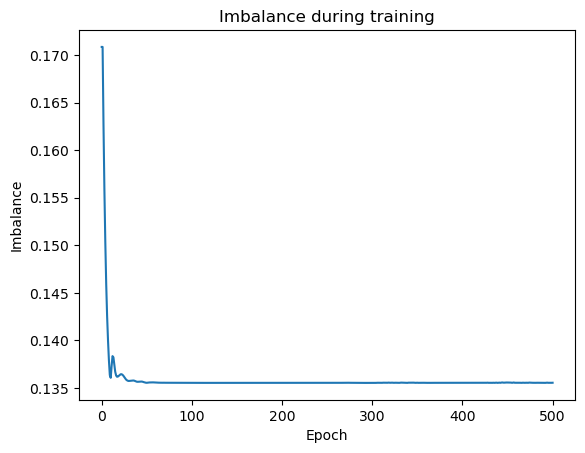

Optimal DII over full data set: 0.135551
[0.14 0.13 0.18 0.06 0.02 0.06 0.03 0.02 0.03 0.05 0.19 0.03]
[0.14 0.13 0.18 0.19]
[[ 1]
 [ 2]
 [ 3]
 [11]]


In [16]:
# train the DII to recover ground-truth metric
dii = DiffImbalance(
    data_A=data_A,  # matrix of shape (N,D_A)
    data_B=data_B,  # matrix of shape (N,D_B)
    periods_A=periods_A,
    periods_B=None,
    seed=seed_val,
    num_epochs=500,
    batches_per_epoch=1,  # no mini-batches
    l1_strength=0.0,  # no l1 regularization
    point_adapt_lambda=True,
    k_init=60,
    k_final=60,
    lambda_factor=0.1,
    params_init=None,  # automatically set to [0.1,0.1,0.1,0.1,0.1]
    optimizer_name="adam",  # possible choices: "sgd", "adam", "adamw"
    learning_rate=1e-2,
    learning_rate_decay=None,  # possible choices: None, "cos", "exp"
    num_points_rows=None,
)
weights, imbs = dii.train()

plt.plot(imbs)
plt.xlabel("Epoch")
plt.ylabel("Imbalance")
plt.title("Imbalance during training")
plt.show()

imb_final, _ = dii.return_final_dii(
    compute_error=False, ratio_rows_columns=None, seed=0, discard_close_ind=0
)
print(f"Optimal DII over full data set: {imb_final:2f}")  # can also be accessed

final_weights = weights[-1]
print(final_weights)
print(final_weights[final_weights > 0.1])
print(np.argwhere(final_weights > 0.1) + 1)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

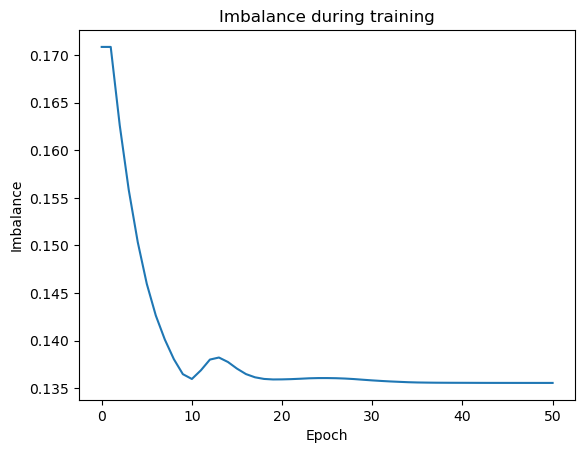

Optimal DII over full data set: 0.135576


In [17]:
# train the DII to recover ground-truth metric
dii = DiffImbalance(
    data_A=data_A,  # matrix of shape (N,D_A)
    data_B=data_B,  # matrix of shape (N,D_B)
    periods_A=periods_A,
    periods_B=None,
    seed=seed_val,
    num_epochs=50,
    batches_per_epoch=1,  # no mini-batches
    l1_strength=0.0,  # no l1 regularization
    point_adapt_lambda=True,
    k_init=60,
    k_final=60,
    lambda_factor=0.1,
    params_init=None,  # automatically set to [0.1,0.1,0.1,0.1,0.1]
    optimizer_name="adam",  # possible choices: "sgd", "adam", "adamw"
    learning_rate=1e-2,
    learning_rate_decay="cos",  # possible choices: None, "cos", "exp"
    num_points_rows=None,
)
weights, imbs = dii.train()

plt.plot(imbs)
plt.xlabel("Epoch")
plt.ylabel("Imbalance")
plt.title("Imbalance during training")
plt.show()

imb_final, _ = dii.return_final_dii(
    compute_error=False, ratio_rows_columns=None, seed=0, discard_close_ind=0
)
print(f"Optimal DII over full data set: {imb_final:2f}")  # can also be accessed

In [18]:
# forward greedy search

import contextlib

with open("6_dE.out", "w") as f:
    with contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        (
            feature_sets_fw_dE,
            diis_fw_dE,
            errors_fw_dE,
            weights_fw_dE,
        ) = dii.forward_greedy_feature_selection(
            n_features_max=10,
            n_best=5,
            compute_error=True,
            ratio_rows_columns=1,
            seed=seed_val,
            discard_close_ind=0,
        )

diis_fw_dE_array = np.array(diis_fw_dE)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

...

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]


Selected feature subsets:
 [[9], [9, 10], [5, 9, 10], [3, 5, 9, 10], [2, 3, 5, 9, 10], [2, 3, 5, 8, 9, 10], [1, 2, 3, 5, 8, 9, 10], [0, 1, 2, 3, 5, 8, 9, 10], [0, 1, 2, 3, 5, 8, 9, 10, 11], [0, 1, 2, 3, 5, 6, 8, 9, 10, 11]]

Forward DIIs: [0.35194891691207886, 0.27107298374176025, 0.1737259030342102, 0.16191552579402924, 0.15103527903556824, 0.1494220644235611, 0.14835354685783386, 0.1475526988506317, 0.14692339301109314, 0.14679934084415436]
Forward Errors: [0.0023892077151685953, 0.0020779790356755257, 0.0017128591425716877, 0.0016390553209930658, 0.0015255167381837964, 0.0015090401284396648, 0.001501980354078114, 0.0014866654528304935, 0.001470878953114152, 0.0014644012553617358]
Forward Weights: [array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0. , 0. ]), array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.05, 0.13,
       0.  ], dtype=float32), array([0.  , 0.  , 0.  , 0.  , 0.  , 0.05, 0.  , 0.  , 0.  , 0.05, 0.16,
       0.  ], dtype=float32), array([0.  , 0

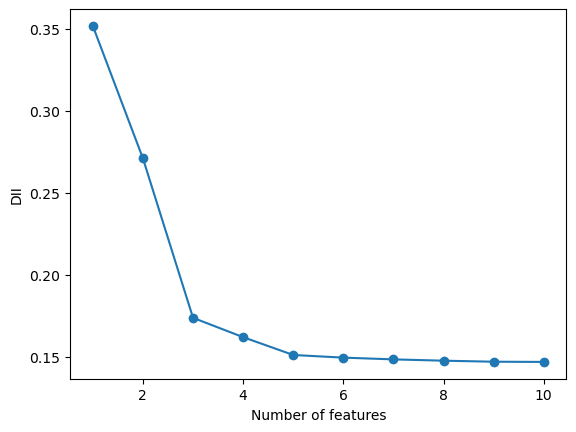

In [19]:
print(f"\nSelected feature subsets:\n {feature_sets_fw_dE}\n")
print("Forward DIIs:", diis_fw_dE)
print("Forward Errors:", errors_fw_dE)
print("Forward Weights:", weights_fw_dE)

plt.xlabel("Number of features")
plt.ylabel("DII")
plt.plot(range(1, len(feature_sets_fw_dE) + 1), diis_fw_dE, "o-")

In [20]:
print("index\tlabel\t\tgroup\t\tatoms\t\thotspot-score\tperiod\t\tsource\n")

for i, (name, group, atoms, score, period, source) in enumerate(
    zip(
        feature_names,
        feature_groups,
        feature_atoms,
        feature_hotspot_scores,
        feature_periods,
        feature_sources,
    )
):
    score_str = f"{score:.6f}" if np.isfinite(score) else "NA"
    print(f"{i}\t{name}\t\t{group}\t\t{atoms}\t\t{score_str}\t\t{period:.6f}\t\t{source}")

index	label		group		atoms		hotspot-score	period		source

0	Bond_15		bonds		15-14		0.942166		0.000000		hotspot
1	Bond_23		bonds		23-21		0.934903		0.000000		hotspot
2	Bond_24		bonds		24-22		0.929868		0.000000		hotspot
3	Extra_Angle_1		angles		3-21-22		0.641958		6.283185		hotspot
4	Dihedral_20		dihedrals		22-21-19-10		0.435100		6.283185		hotspot
5	Dihedral_21		dihedrals		23-21-19-10		0.506646		6.283185		hotspot
6	Dihedral_22		dihedrals		24-22-21-19		0.663663		6.283185		hotspot
7	Dihedral_40		dihedrals		42-23-21-19		0.676802		6.283185		hotspot
8	Dihedral_41		dihedrals		43-23-21-19		0.665942		6.283185		hotspot
9	Extra_Dihedral_1		dihedrals		22-21-19-3		0.528865		6.283185		hotspot
10	Mode_Bond_S1		explicit_mode		7_DIIB bond		NA		0.000000		explicit
11	Mode_Pyramidalization_S1		explicit_mode		7_DIIB pyramidalization		NA		6.283185		explicit


In [ ]:
print("\nGreedy subsets with feature names:\n")
for subset in feature_sets_fw_dE:
    print([feature_names[i] for i in subset])


Greedy subsets with feature names:

['Extra_Dihedral_1']
['Extra_Dihedral_1', 'Mode_Bond_S1']
['Dihedral_21', 'Extra_Dihedral_1', 'Mode_Bond_S1']
['Extra_Angle_1', 'Dihedral_21', 'Extra_Dihedral_1', 'Mode_Bond_S1']
['Bond_24', 'Extra_Angle_1', 'Dihedral_21', 'Extra_Dihedral_1', 'Mode_Bond_S1']
['Bond_24', 'Extra_Angle_1', 'Dihedral_21', 'Dihedral_41', 'Extra_Dihedral_1', 'Mode_Bond_S1']
['Bond_23', 'Bond_24', 'Extra_Angle_1', 'Dihedral_21', 'Dihedral_41', 'Extra_Dihedral_1', 'Mode_Bond_S1']
['Bond_15', 'Bond_23', 'Bond_24', 'Extra_Angle_1', 'Dihedral_21', 'Dihedral_41', 'Extra_Dihedral_1', 'Mode_Bond_S1']
['Bond_15', 'Bond_23', 'Bond_24', 'Extra_Angle_1', 'Dihedral_21', 'Dihedral_41', 'Extra_Dihedral_1', 'Mode_Bond_S1', 'Mode_Pyramidalization_S1']
['Bond_15', 'Bond_23', 'Bond_24', 'Extra_Angle_1', 'Dihedral_21', 'Dihedral_22', 'Dihedral_41', 'Extra_Dihedral_1', 'Mode_Bond_S1', 'Mode_Pyramidalization_S1']


: 